=== Advanced Time Series Forecasting with LSTM ===

1. Generating multivariate time series dataset...
Dataset shape: (1500, 4)
Features: ['temperature', 'humidity', 'pressure', 'synthetic']

2. Preprocessing data...
Training sequences: (1176, 24, 4)
Test sequences: (276, 24, 4)

3. Performing hyperparameter tuning...
Reloading Tuner from tuning/lstm_forecasting/tuner0.json
Best hyperparameters found:
  lstm_units: 32
  dropout_rate: 0.2
  learning_rate: 0.01
  n_layers: 1
  lstm_units_1: 96
  lstm_units_2: 96

4. Training final model...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0086 - mae: 0.0733 - val_loss: 0.0030 - val_mae: 0.0437
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0038 - mae: 0.0489 - val_loss: 0.0051 - val_mae: 0.0605
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0045 - mae: 0.0536 - val_loss: 0.0045 - val_mae: 0.0566
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0035 - mae: 0.0472 - val_loss: 0.0033 - v

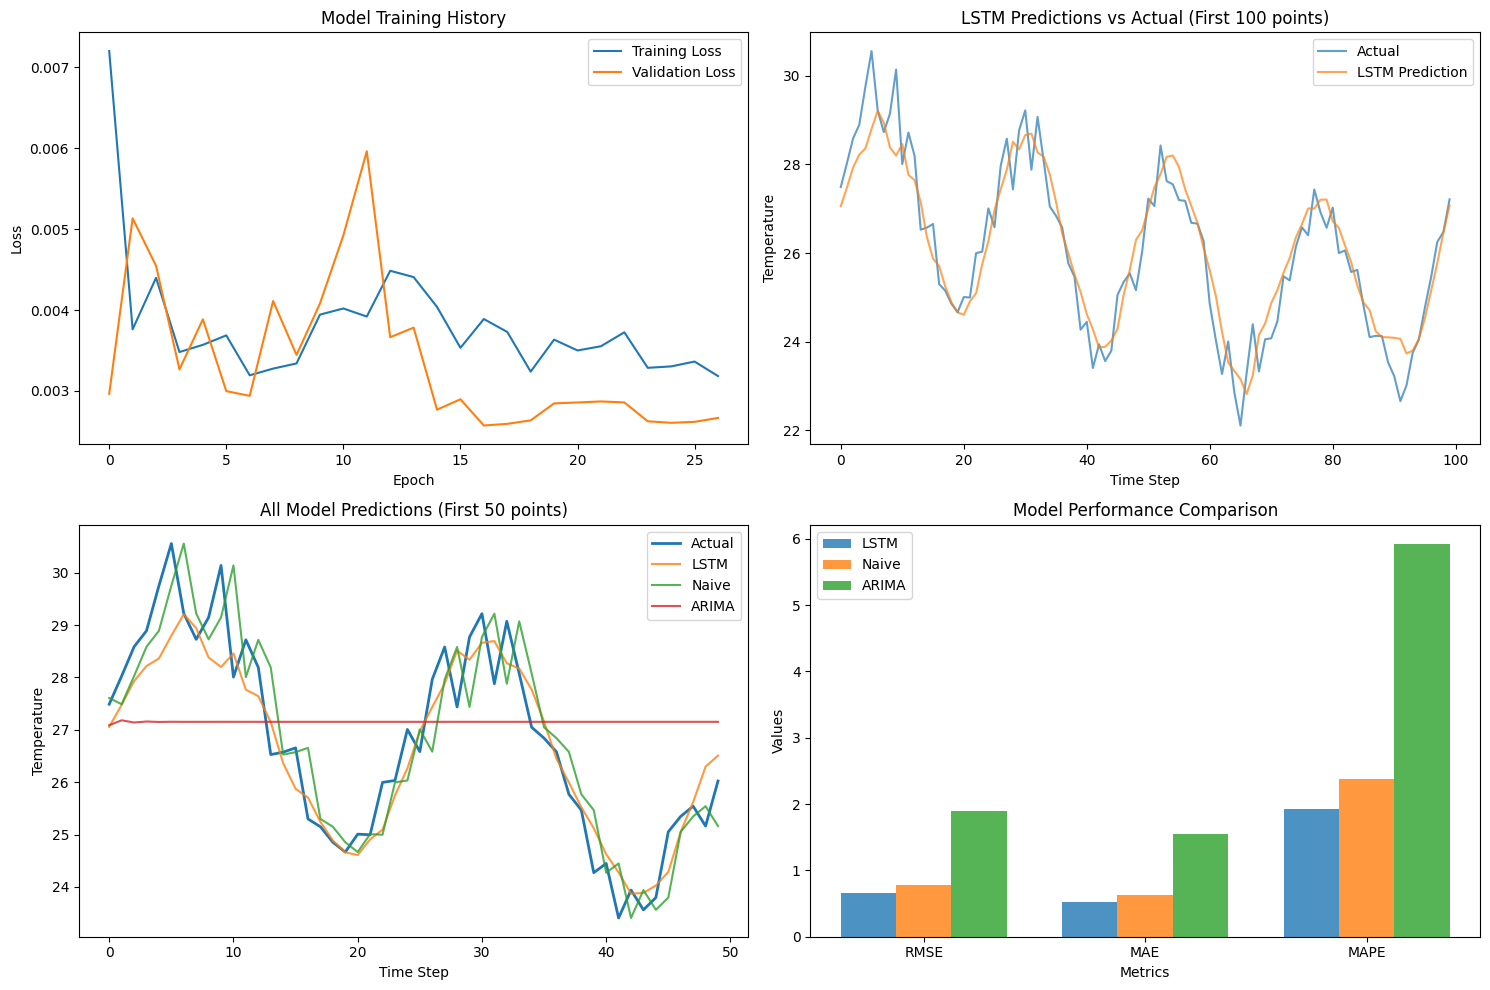

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Data Generation and Preprocessing
def generate_multivariate_timeseries(n_obs=1500, start_date='2020-01-01'):
    """
    Generate a synthetic multivariate time series dataset with trends, seasonality,
    and noise representative of complex sensor/financial data.

    Parameters:
    - n_obs: Number of observations (default: 1500)
    - start_date: Start date for the time series

    Returns:
    - DataFrame with datetime index and multiple features
    """
    dates = pd.date_range(start=start_date, periods=n_obs, freq='H')

    # Base trend components
    t = np.arange(n_obs)
    trend1 = 0.005 * t
    trend2 = -0.003 * t

    # Seasonal components (daily and weekly cycles)
    daily_seasonality = 2 * np.sin(2 * np.pi * t / 24)
    weekly_seasonality = 1.5 * np.sin(2 * np.pi * t / (24 * 7))

    # Generate features with correlations
    np.random.seed(42)

    # Target variable: temperature-like sensor reading
    temperature = (20 + trend1 +
                   daily_seasonality +
                   weekly_seasonality +
                   np.random.normal(0, 0.5, n_obs))

    # Feature 1: humidity (correlated with temperature)
    humidity = (60 + trend2 +
                0.8 * daily_seasonality +
                0.3 * weekly_seasonality +
                np.random.normal(0, 1, n_obs))

    # Feature 2: pressure (different seasonal pattern)
    pressure_seasonality = 1.2 * np.cos(2 * np.pi * t / (24 * 3))
    pressure = (1013 + 0.001 * t +
                pressure_seasonality +
                np.random.normal(0, 0.3, n_obs))

    # Feature 3: synthetic feature with noise
    synthetic = (0.5 * temperature +
                 0.3 * humidity -
                 0.2 * pressure +
                 np.random.normal(0, 2, n_obs))

    # Create DataFrame
    df = pd.DataFrame({
        'temperature': temperature,
        'humidity': humidity,
        'pressure': pressure,
        'synthetic': synthetic
    }, index=dates)

    # Introduce some missing values (2%)
    mask = np.random.random(n_obs) < 0.02
    df.loc[mask, 'humidity'] = np.nan

    return df

class TimeSeriesPreprocessor:
    """
    Comprehensive time series preprocessing class for LSTM models.
    Handles missing values, scaling, and sequence creation.
    """

    def __init__(self, sequence_length=24, target_col='temperature'):
        """
        Initialize preprocessor.

        Parameters:
        - sequence_length: Length of input sequences for LSTM
        - target_col: Name of target variable column
        """
        self.sequence_length = sequence_length
        self.target_col = target_col
        self.scalers = {}

    def handle_missing_values(self, df, method='linear'):
        """
        Handle missing values in the time series data.

        Parameters:
        - df: Input DataFrame
        - method: Interpolation method ('linear', 'ffill', 'bfill')

        Returns:
        - DataFrame with missing values handled
        """
        df_clean = df.copy()

        if method == 'linear':
            df_clean = df_clean.interpolate(method='linear')
        elif method == 'ffill':
            df_clean = df_clean.ffill()
        elif method == 'bfill':
            df_clean = df_clean.bfill()

        # If any missing values remain, use forward fill
        df_clean = df_clean.ffill().bfill()

        return df_clean

    def fit_scalers(self, df):
        """
        Fit MinMax scalers for each feature.

        Parameters:
        - df: Training DataFrame
        """
        from sklearn.preprocessing import MinMaxScaler

        for col in df.columns:
            self.scalers[col] = MinMaxScaler()
            self.scalers[col].fit(df[[col]])

    def transform_data(self, df):
        """
        Transform data using fitted scalers.

        Parameters:
        - df: Input DataFrame

        Returns:
        - Scaled numpy array
        """
        scaled_data = []
        for col in df.columns:
            scaled_col = self.scalers[col].transform(df[[col]])
            scaled_data.append(scaled_col)

        return np.hstack(scaled_data)

    def inverse_transform_target(self, scaled_target):
        """
        Inverse transform the target variable.

        Parameters:
        - scaled_target: Scaled target values

        Returns:
        - Original scale target values
        """
        return self.scalers[self.target_col].inverse_transform(
            scaled_target.reshape(-1, 1)
        ).flatten()

    def create_sequences(self, data):
        """
        Create input sequences and targets for LSTM training.

        Parameters:
        - data: Scaled numpy array

        Returns:
        - X: Input sequences (samples, sequence_length, features)
        - y: Target values
        """
        X, y = [], []
        target_idx = list(self.scalers.keys()).index(self.target_col)

        for i in range(len(data) - self.sequence_length):
            X.append(data[i:(i + self.sequence_length)])
            y.append(data[i + self.sequence_length, target_idx])

        return np.array(X), np.array(y)

# LSTM Model Implementation
def build_lstm_model(sequence_length, n_features, lstm_units=50, dropout_rate=0.2, learning_rate=0.001):
    """
    Build and compile LSTM model for time series forecasting.

    Parameters:
    - sequence_length: Length of input sequences
    - n_features: Number of input features
    - lstm_units: Number of LSTM units
    - dropout_rate: Dropout rate for regularization
    - learning_rate: Learning rate for optimizer

    Returns:
    - Compiled Keras model
    """
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=(sequence_length, n_features)),
        Dropout(dropout_rate),
        LSTM(lstm_units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Hyperparameter Tuning
def perform_hyperparameter_tuning(X_train, y_train, sequence_length, n_features):
    """
    Perform systematic hyperparameter tuning using Keras Tuner.

    Parameters:
    - X_train: Training sequences
    - y_train: Training targets
    - sequence_length: Length of input sequences
    - n_features: Number of input features

    Returns:
    - Best model and hyperparameters
    """
    import kerastuner as kt
    from tensorflow.keras.models import Sequential # Import Sequential here
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    def build_model(hp):
        lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
        dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
        learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        n_layers = hp.Int('n_layers', min_value=1, max_value=3, step=1)

        model = Sequential()
        model.add(LSTM(lstm_units, return_sequences=(n_layers > 1),
                      input_shape=(sequence_length, n_features)))
        model.add(Dropout(dropout_rate))

        for i in range(1, n_layers):
            return_sequences = (i < n_layers - 1)
            model.add(LSTM(hp.Int(f'lstm_units_{i}', min_value=32, max_value=128, step=32),
                          return_sequences=return_sequences))
            model.add(Dropout(dropout_rate))

        model.add(Dense(25, activation='relu'))
        model.add(Dense(1))

        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

        return model

    tuner = kt.RandomSearch(
        build_model,
        objective='val_loss',
        max_trials=20,
        executions_per_trial=1,
        directory='tuning',
        project_name='lstm_forecasting'
    )

    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=3)

    # Create custom validation generator for time series split
    for train_idx, val_idx in tscv.split(X_train):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        tuner.search(X_train_fold, y_train_fold,
                    epochs=50,
                    validation_data=(X_val_fold, y_val_fold),
                    batch_size=32,
                    verbose=0)

    return tuner.get_best_models(num_models=1)[0], tuner.get_best_hyperparameters()[0]

# Baseline Models
class BaselineModels:
    """
    Implement baseline models for performance comparison.
    """

    @staticmethod
    def naive_forecast(y_test, y_train=None):
        """
        Naive forecast: last observed value.
        """
        return np.roll(y_test, 1)

    @staticmethod
    def arima_forecast(train_data, n_forecast_steps, order=(1,1,1)):
        """
        ARIMA model forecast.

        Parameters:
        - train_data: Data to train the ARIMA model.
        - n_forecast_steps: Number of steps to forecast.
        - order: ARIMA order (p,d,q).

        Returns:
        - Forecasted values.
        """
        try:
            from statsmodels.tsa.arima.model import ARIMA

            model = ARIMA(train_data, order=order)
            fitted_model = model.fit()
            # Forecast for the specified number of steps
            forecast = fitted_model.forecast(steps=n_forecast_steps)
            return forecast
        except Exception as e:
            print(f"ARIMA failed with error: {e}. Falling back to naive forecast.")
            # Fallback to naive forecast if ARIMA fails
            # This fallback might still have length mismatch if not handled carefully
            # For now, return an array of NaNs or raise the error for clarity during debugging
            return np.full(n_forecast_steps, np.nan)

# Evaluation Metrics
def calculate_metrics(y_true, y_pred, y_train=None):
    """
    Calculate comprehensive time series forecasting metrics.

    Parameters:
    - y_true: True values
    - y_pred: Predicted values
    - y_train: Training values (for MASE calculation)

    Returns:
    - Dictionary of metrics
    """
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    import numpy as np

    # Ensure y_true and y_pred have the same length
    if len(y_true) != len(y_pred):
        min_len = min(len(y_true), len(y_pred))
        y_true = y_true[:min_len]
        y_pred = y_pred[:min_len]
        print(f"Warning: y_true and y_pred lengths mismatched. Truncating to {min_len} samples.")

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # Avoid division by zero in MAPE if y_true contains zeros
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if np.all(y_true != 0) else np.nan

    # Calculate MASE
    if y_train is not None:
        # Ensure y_train is not empty and has more than one element for naive forecast
        if len(y_train) > 1:
            naive_forecast = np.roll(y_train, 1)
            mae_naive = mean_absolute_error(y_train[1:], naive_forecast[1:])
            mase = mae / mae_naive if mae_naive != 0 else float('inf')
        else:
            mase = np.nan # Not enough data to calculate naive MAE
    else:
        mase = None

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'MASE': mase
    }

# Main Execution
def main():
    """
    Main function to execute the complete forecasting pipeline.
    """
    print("=== Advanced Time Series Forecasting with LSTM ===")

    # 1. Generate dataset
    print("\n1. Generating multivariate time series dataset...")
    df = generate_multivariate_timeseries(n_obs=1500)
    print(f"Dataset shape: {df.shape}")
    print(f"Features: {list(df.columns)}")

    # 2. Data preprocessing
    print("\n2. Preprocessing data...")
    preprocessor = TimeSeriesPreprocessor(sequence_length=24, target_col='temperature')
    df_clean = preprocessor.handle_missing_values(df)

    # Split data (80% train, 20% test)
    split_idx = int(0.8 * len(df_clean))
    train_df = df_clean.iloc[:split_idx]
    test_df = df_clean.iloc[split_idx:]

    # Fit scalers on training data only
    preprocessor.fit_scalers(train_df)

    # Transform data
    train_scaled = preprocessor.transform_data(train_df)
    test_scaled = preprocessor.transform_data(test_df)

    # Create sequences
    X_train, y_train = preprocessor.create_sequences(train_scaled)
    X_test, y_test = preprocessor.create_sequences(test_scaled)

    print(f"Training sequences: {X_train.shape}")
    print(f"Test sequences: {X_test.shape}")

    # 3. Hyperparameter tuning and model training
    print("\n3. Performing hyperparameter tuning...")
    best_model, best_hps = perform_hyperparameter_tuning(X_train, y_train,
                                                        X_train.shape[1], X_train.shape[2])

    print("Best hyperparameters found:")
    for param, value in best_hps.values.items():
        print(f"  {param}: {value}")

    # Train final model with best hyperparameters
    print("\n4. Training final model...")
    history = best_model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=100,
        validation_split=0.2,
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
        ]
    )

    # 4. Model evaluation
    print("\n5. Evaluating models...")

    # LSTM predictions
    lstm_pred_scaled = best_model.predict(X_test).flatten()
    lstm_pred = preprocessor.inverse_transform_target(lstm_pred_scaled)
    y_test_original = preprocessor.inverse_transform_target(y_test)

    # Baseline predictions
    naive_pred = BaselineModels.naive_forecast(y_test_original)

    # Pass the correct number of forecast steps to ARIMA
    arima_pred = BaselineModels.arima_forecast(
        train_df['temperature'].values,
        len(y_test_original) # Corrected: Forecast for the length of y_test_original
    )

    # Calculate metrics
    lstm_metrics = calculate_metrics(y_test_original, lstm_pred, train_df['temperature'].values)
    naive_metrics = calculate_metrics(y_test_original, naive_pred, train_df['temperature'].values)
    arima_metrics = calculate_metrics(y_test_original, arima_pred, train_df['temperature'].values)

    # Create comparison table
    metrics_df = pd.DataFrame({
        'LSTM': lstm_metrics,
        'Naive': naive_metrics,
        'ARIMA': arima_metrics
    })

    print("\n=== Performance Comparison ===")
    print(metrics_df.round(4))

    # 5. Visualization
    plt.figure(figsize=(15, 10))

    # Plot training history
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot predictions vs actual
    plt.subplot(2, 2, 2)
    plt.plot(y_test_original[:100], label='Actual', alpha=0.7)
    plt.plot(lstm_pred[:100], label='LSTM Prediction', alpha=0.7)
    plt.title('LSTM Predictions vs Actual (First 100 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Temperature')
    plt.legend()

    # Plot all model comparisons
    plt.subplot(2, 2, 3)
    plt.plot(y_test_original[:50], label='Actual', linewidth=2)
    plt.plot(lstm_pred[:50], label='LSTM', alpha=0.8)
    plt.plot(naive_pred[:50], label='Naive', alpha=0.8)
    plt.plot(arima_pred[:50], label='ARIMA', alpha=0.8)
    plt.title('All Model Predictions (First 50 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Temperature')
    plt.legend()

    # Plot metrics comparison
    plt.subplot(2, 2, 4)
    metrics_to_plot = ['RMSE', 'MAE', 'MAPE']
    x_pos = np.arange(len(metrics_to_plot))
    width = 0.25

    plt.bar(x_pos - width, [lstm_metrics[m] for m in metrics_to_plot],
            width, label='LSTM', alpha=0.8)
    plt.bar(x_pos, [naive_metrics[m] for m in metrics_to_plot],
            width, label='Naive', alpha=0.8)
    plt.bar(x_pos + width, [arima_metrics[m] for m in metrics_to_plot],
            width, label='ARIMA', alpha=0.8)

    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.title('Model Performance Comparison')
    plt.xticks(x_pos, metrics_to_plot)
    plt.legend()

    plt.tight_layout()
    plt.savefig('forecasting_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'model': best_model,
        'preprocessor': preprocessor,
        'metrics': metrics_df,
        'best_hyperparameters': best_hps.values
    }

if __name__ == "__main__":
    results = main()
